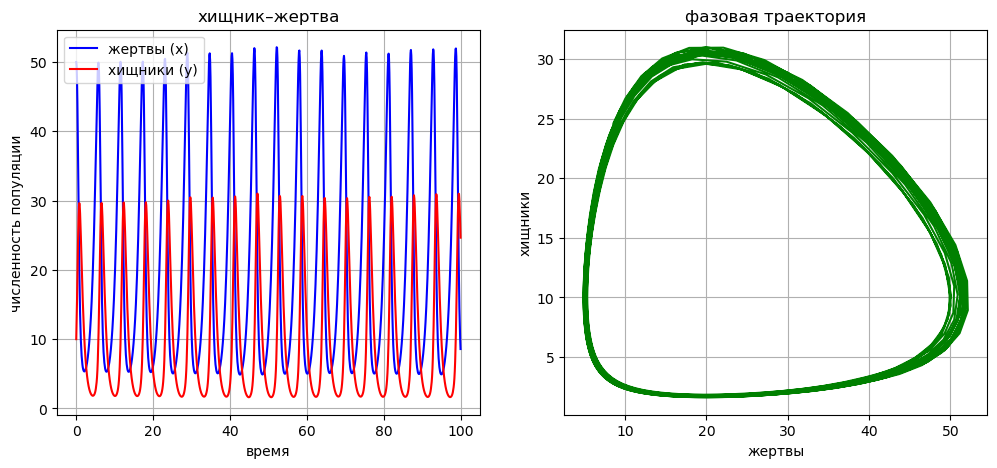

численность жертв: 8.574832703564839
численность хищников: 24.647840054404213


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

alpha = 1.0 # коэффициент рождаемости жертв -> больше зайцев, чаще циклы
beta = 0.1 # коэффициент убийства жертв хищниками -> зайцы подавлены
gamma = 1.5 # коэффициент убыли хищников -> волки умирают быстрее
delta = 0.075 # коэффициент воспроизводства хищников от поедания жертв -> волки восстонавливаются быстрее
x0 = 50 # жертвы
y0 = 10 # хищники

T = 100.0

def f(t, z):
    x, y = z
    dxdt = (alpha - beta * y) * x
    dydt = (delta * x - gamma) * y
    return [dxdt, dydt]

solution = solve_ivp(
    f,
    (0, T),
    [x0, y0],
    t_eval=np.linspace(0, T, 1000),
    method='RK45'
)

t = solution.t
x = solution.y[0]
y = solution.y[1]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, x, 'b-', label='жертвы (x)')
plt.plot(t, y, 'r-', label='хищники (y)')
plt.xlabel('время')
plt.ylabel('численность популяции')
plt.title('хищник–жертва')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x, y, 'g-')
plt.xlabel('жертвы')
plt.ylabel('хищники')
plt.title('фазовая траектория')
plt.grid(True)

plt.show()

print(f'численность жертв: {x[-1]}')
print(f'численность хищников: {y[-1]}')